**Projeto de Ciência de dados**<br>
Isac Renan Miranda de Oliveira

### Preparando o ambiente

In [1]:
# Preparando ambiente
import pandas as pd
from datetime import datetime
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


### Projeto de Machine Learning não supervisionado

#### Objetivo

Este projeto tem como objetivo aplicar técnicas de aprendizado não supervisionado, com foco em algoritmos de clusterização, para identificar padrões e segmentações relevantes em dados provenientes de um sistema de análises clínicas.

A proposta é agrupar registros com características semelhantes — como tipos de exames realizados, frequência, temporalidade e ossíveis padrões operacionais — visando gerar insights exploratórios sobre o comportamento da demanda laboratorial e possíveis perfis de atendimento.

A análise tem caráter exclusivamente exploratório e educacional, sem qualquer finalidade comercial. Todos os dados utilizados são anonimizados, garantindo a preservação da privacidade e conformidade com boas práticas de tratamento de dados.

#### Conhecendo o Dataset

A partir da análise inicial do dataset, foi identificado que as primeiras linhas não correspondem ao cabeçalho estruturado da base, mas sim a metadados oriundos da exportação do sistema (como filtros aplicados e período do relatório).

Além disso, foram identificadas colunas contendo informações sensíveis, como nome do paciente e usuário responsável pelo processamento dos exames.

Dessa forma, será necessário realizar um pré-processamento dos dados, incluindo:

remoção de linhas não estruturadas
ajuste correto do cabeçalho
tratamento ou exclusão de dados sensíveis

Essas etapas são fundamentais para garantir a qualidade da análise e a conformidade com boas práticas de tratamento de dados.

In [2]:
# Importando os dados de Excel
# header 6 para eliminar as 5 primeiras linhas de cabeçalho com metadados do documento original
df = pd.read_excel('../dataset/dataset.xlsx', header= 6)
df = df.drop(columns=['Paciente', 'Nome do Usuário', 'Valor R$', 'Valor Final'])# Excluindo colunas com dados sensíveis - Nome e usuário e colunas que não serão usadas


In [3]:
# verificando dataset
df.dtypes

Data Cad.        str
Código        object
Convênio         str
Exames           str
Sexo             str
Data Nasc.       str
dtype: object

In [4]:
# Shape do dataset antes de tratamentp
df.shape

(52743, 6)

O primeiro desafio encontrado após o carregamento do dataset é que os dados estão todos em formato de string, isso impossibilita que análises sejam feitoas devido ao tipo de formato dos dados, que basicamente são textos. Uma etapa rigorosa de tratamento de dados será feita a seguir.

### Convertendo tipos de dados

In [5]:
# Data de nascimento
# Converter str para formarto datetime
df['Data Nasc.'] = pd.to_datetime(
    df['Data Nasc.'],
    format='%d/%m/%Y',
    errors= 'coerce'# Se tiver alguma data nula transforma em Nat(formato nulo em datetime)
    )

# Pegando a data atual para cálculo de idade
hoje = datetime.today()

# Criando e calculando coluna de Idade
df['Idade'] = hoje.year - df['Data Nasc.'].dt.year

# Covertendo coluna Data Cad para datetime
df['Data Cad.'] = pd.to_datetime(df['Data Cad.'], dayfirst=True, errors='coerce')


In [6]:
# Colunas numéricas

# Convertendo Idade para Int
df['Idade'] = df['Idade'].astype('Int64')

# Colunas categóricas
df['Sexo'] = df['Sexo'].astype('category')
df['Convênio'] = df['Convênio'].astype('category')


# Garantindo formato string para coluna Exames e Código
df['Exames'] = df['Exames'].astype('str')
df['Código'] = df['Código'].astype('str')

In [7]:
# Excluindo coluna original de datas pois a mesma foi usada para cálculo de idade.
df = df.drop(columns='Data Nasc.')

# Remove linhas que não tem data preenchida.
df = df[df['Data Cad.'].notna()]

In [8]:
df.dtypes

Data Cad.    datetime64[us]
Código                  str
Convênio           category
Exames                  str
Sexo               category
Idade                 Int64
dtype: object

In [9]:
# Verificando Nulos
df.isna().sum()

Data Cad.    0
Código       0
Convênio     0
Exames       0
Sexo         0
Idade        6
dtype: int64

In [10]:
# Apagando dados nulos
df = df.dropna().reset_index(drop=True)

df.isna().sum()

Data Cad.    0
Código       0
Convênio     0
Exames       0
Sexo         0
Idade        0
dtype: int64

In [11]:
# Verificando dataset após processamento
df.shape

(52729, 6)

In [12]:
# Visualizando dataset em dataframe
df.head()

,Data Cad.,Código,Convênio,Exames,Sexo,Idade
0,2025-01-01,0112041,001,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GASOV",M,90
1,2025-01-01,0112042,001,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GASOV",M,74
2,2025-01-01,0112043,PART,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GASOV,...",M,32
3,2025-01-01,0112044,001,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GASOV",M,50
4,2025-01-01,0112045,001,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GAS",F,89


In [13]:
df.tail()

,Data Cad.,Código,Convênio,Exames,Sexo,Idade
52724,2025-08-17,0165026,001,URI,F,21
52725,2025-08-17,0165027,SUS,"HG, URE, CRE, CCCT, SOD, POT, URI",M,92
52726,2025-08-17,0165028,SUS,"HG, SOD, POT, URE, CRE, PCRU",M,72
52727,2025-08-17,0165029,SUS,"HG, PCRU, SOD, POT, URE, CRE",F,81
52728,2025-08-17,0165030,001,URI,F,91


### Feature Exames



Após a limpeza e padronização dos dados, foi identificado que a variável **Exames** ainda está em formato de String. Isso impossibilita o seu uso em qualquer algorítmo de machine learning. Além disso, os exames estão concatenados em uma única célula e separados por vírgula. Por isso, é necessário a sua transformação em dados estruturados para uso em machine learning.

**Estratégia usada**

A técnica utilizada para resolver esse problema foi a **One-Hot Encoding**. Antes da aplicação da técnica foi realizada um estudo exploratório da variável.

In [14]:
# Criando uma colunas com a quantidade de exames para cada linha através da função count
df['qtd_exames'] = df['Exames'].str.count(',') + 1


df['qtd_exames'].describe()

count    52729.000000
mean         9.000531
std          9.075916
min          1.000000
25%          2.000000
50%          6.000000
75%         13.000000
max        158.000000
Name: qtd_exames, dtype: float64

Após o **describe** da nova coluna, foi observado que há valor máximo de exames de 158. O que chama muito atenção, pois, essa quantidade de exames para um único paciente é muito improvável.

<Axes: >

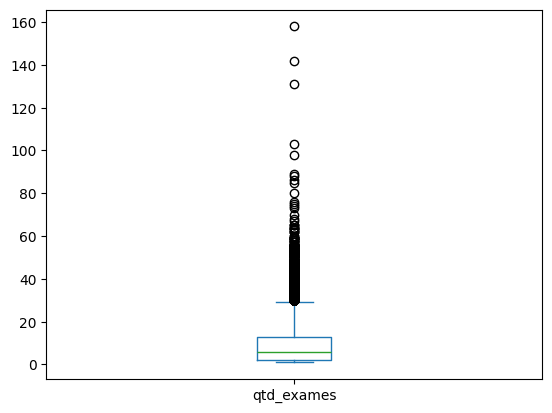

In [15]:
# Visualizando boxplot
# Usando o gráfico de boxplot direto da biblioteca pandas pa visualização da coluna Qtd_exames

df['qtd_exames'].plot.box()


Com a análise primária do bloxspot e o **describe** é evidente que o dataset está polído com muitos outliers, Sendo assim, para maior entendimento e confirmação, foi plotado o mesmo boxplot com o parâmetro **showfliers**, que permite plotar o gráfico sem a presença dos outliers. 

<Axes: >

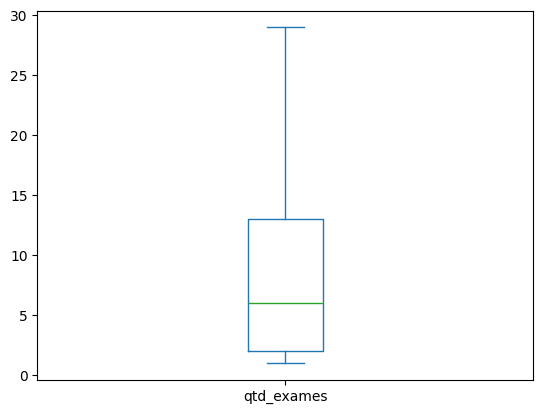

In [16]:
# Visualizando a frequencia real dos exames (sem outliers)
df['qtd_exames'].plot.box(showfliers=False)

Fica evidente que aqui que a análise foi satisfatória para entender o comportamento da variável.

**Análise Exploratória — Quantidade de Exames**

A distribuição apresenta mediana de aproximadamente 6 exames por registro, com 50% dos dados concentrados entre 2 e 13 exames. Observa-se uma assimetria à direita, indicando a presença de atendimentos com maior número de exames, porém ainda dentro de limites plausíveis.

Valores superiores a 30 exames foram considerados outliers e removidos, por representarem possíveis inconsistências na estrutura dos dados (como registros concatenados ou erros de exportação, que ainda serão checados).

A variável demonstra boa variabilidade e se mostra adequada para utilização em análises posteriores, incluindo algoritmos de clusterização, por refletir diferentes perfis de complexidade nos atendimentos laboratoriais.

#### Entendendo Outliers


Diante do cenário atual da variável Exames, optei por realizar uma análise aprofundada sobre os outliers que foram evidenciados, afim de entender o real motivo da presença desses cadastros, já que, é improvavel os valores totais de exames realizados neles.

In [17]:
# Filtrando apenas cadastros que tenham mais de 30 exames cadastrados
outliers = (df['qtd_exames'] > 30).sum()
outliers

np.int64(1607)

In [18]:
# Visualizando exemplos de outliers
df.sort_values('qtd_exames', ascending= False) [['Código', 'Exames', 'qtd_exames']].head(10)

,Código,Exames,qtd_exames
49058,0161334,"5NUCA, A1GLA, ACERA, CAMA, ACTHA, ADEA, ADHA, ...",158
49065,0161341,"F23A, F24A, F25A, F26A, F27A, F2A, F3A, F31A, ...",142
49066,0161342,"HZGA, HZMA, I1A, I4A, I6A, I70A, IEA, IFGA, IF...",131
48614,0160888,"A1AA, A1AFA, AACHA, AB2GA, CCPA, ACETA, ADNAA,...",103
48611,0160885,"VRSA, WIDA, XFPA, ZIKAA, ZIUA, CALPA, F245A, F...",98
16222,0128352,"HG, FER, FTI, TRF, CFF, TRI, APA, APB, FIB, TA...",89
48612,0160886,"BIOA, VPLA, VVTA, ZINA, CARBA, FX3A, IGDA, PFU...",88
50515,0162805,"HG, GLI, HBGLI, TRI, URE, CRE, SOD, POT, TSH, ...",86
10892,0123007,"HG, HBGLI, GLI, FTI, AMI, CRE, URE, FOS, FIB, ...",85
10891,0123006,"HG, VHS, HBGLI, GLI, FTI, AMI, LSE, CRE, URE, ...",80


**Conclusão sobre Outliers**<br>
Durante a análise exploratória da variável Qtd_exames, foram identificados registros com valores significativamente acima do padrão observado, chegando a mais de 100 exames por cadastro. Esses valores são inconsistentes com a prática operacional esperada em um contexto laboratorial, indicando possíveis problemas como erros de exportação, registros duplicados ou concatenação indevida de dados.

Diante desse cenário, destaca-se o papel do analista de dados não apenas na identificação de anomalias, mas também na comunicação estruturada dessas inconsistências aos setores responsáveis, permitindo a investigação da causa raiz e a melhoria contínua da qualidade dos dados.

Como ação recomendada, tais registros poderiam ser consolidados em um relatório específico e encaminhados para validação junto às áreas responsáveis pelo sistema de origem.

Para fins deste projeto, e considerando seu caráter exploratório, optou-se por remover os outliers (valores acima de 30 exames por registro), de modo a preservar a coerência analítica e evitar distorções nos modelos de clusterização.

Essa decisão visa garantir que os padrões identificados reflitam comportamentos reais e representativos da rotina laboratorial.

In [19]:
# Excluindo outliers
total_antes = df.shape[0]

df = df[df['qtd_exames'] <= 30]

total_depois = df.shape[0]

print(f'Removidos: {total_antes - total_depois} ({((total_antes - total_depois)/total_antes)*100:.2f}%)')

Removidos: 1607 (3.05%)


In [20]:
# Validando exclusão de outliers
# 52729 - 1607 (Outliers)
df.shape

(51122, 7)

**Impacto da Remoção de Outliers**

Esses registros representam aproximadamente 3,05% do dataset total, indicando que a remoção não compromete a representatividade dos dados, mas contribui significativamente para a melhoria da qualidade analítica.
A exclusão desses valores visa reduzir ruídos e evitar distorções nas etapas posteriores de modelagem, especialmente em algoritmos sensíveis à distribuição dos dados, como técnicas de clusterização.

<Axes: title={'center': 'Distribuição dos dados'}, ylabel='Frequency'>

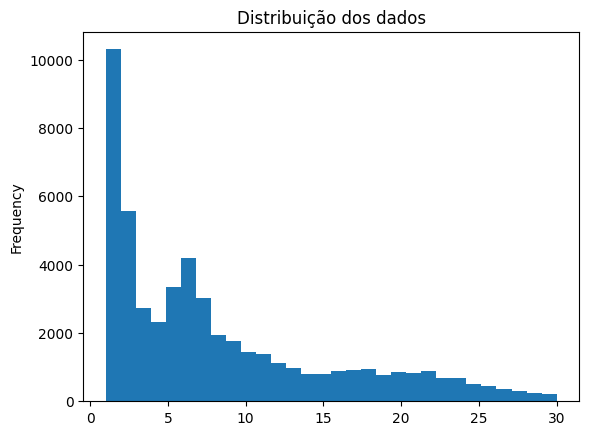

In [21]:
# Visualizando distribuição dos dados após tratamento
df['qtd_exames'].plot.hist(
    bins= 30,
    title = 'Distribuição dos dados',
)

### Codificação One-Hot Encoding


Antes da aplicação de codificação, foi feito um estudo criterioso sobre a dimensionalidade que isso poderia gerar ao dataset.

In [22]:
# Verificar dimensionalidade antes de aplicar codificação.

exames_unicos = (df['Exames'] 
                .str.split(',')# Splita nas vírgulas contidas nas strings
                .explode()# Transforma cada item do Split em uma linha
                .str.strip()# Remove espaços
                .unique()# Pega todos os valores únicos e monta uma lista
)
                    
print(f'Exames únicos: {len(exames_unicos)}')                   
           

Exames únicos: 931


In [23]:
# Entendendo a frequencia dos exames

frequencia = (
            df['Exames']
            .str.split(',')# Splita nas vírgulas contidas nas strings
            .explode()# Transforma cada item do Split em uma linha
            .str.strip()# Remove espaços
            .value_counts()
            )

frequencia.describe()

count      931.000000
mean       443.801289
std       2372.885341
min          1.000000
25%          1.000000
50%          6.000000
75%         41.500000
max      38226.000000
Name: count, dtype: float64

In [24]:
frequencia.head(20) # 20 exames mais pedidos

Exames
HG       38226
CRE      25761
URE      23149
POT      18366
SOD      17678
URI      16238
TRI      14040
GLI      12979
TGO      11866
TGP      11761
TSH      11586
PCRU     10314
HBGLI    10117
VD        9978
V12       9771
T4L       8932
COL       8846
HDL       8338
LDL       8203
VLDL      7168
Name: count, dtype: int64

In [25]:
frequencia.tail(20)# 20 exames mais raros

Exames
ANAA     1
DSTPA    1
UREIA    1
OSMU     1
ACULT    1
VITB2    1
BACLI    1
CHB      1
PT       1
CLNAA    1
T3LA     1
P24A     1
RACA     1
DHTA     1
HPIA     1
PBNPA    1
ELFPA    1
KAPPA    1
IGAA     1
PARA     1
Name: count, dtype: int64

Após uma breve análise da distribuição dos exames, obteve-se que há 931 exames únicos distribuidos nos cadastros, tembém foi checado a frequencia com que os exames aparecem. O desafio aqui foi estabelecer um ponto de corte ideal para se obter a melhor representatividade possível desses exames e evitar ruido no modelo.

<Axes: ylabel='Frequency'>

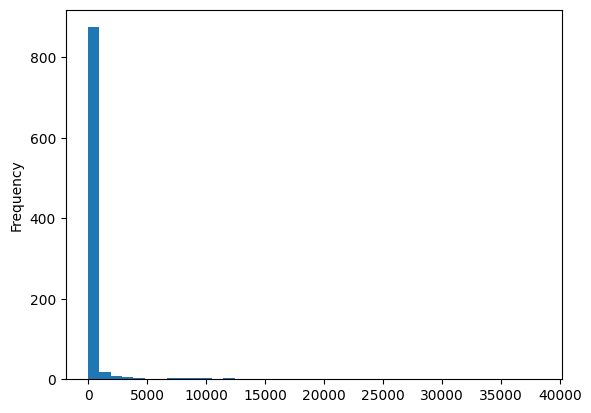

In [26]:
frequencia.plot.hist(bins=40)

<Axes: >

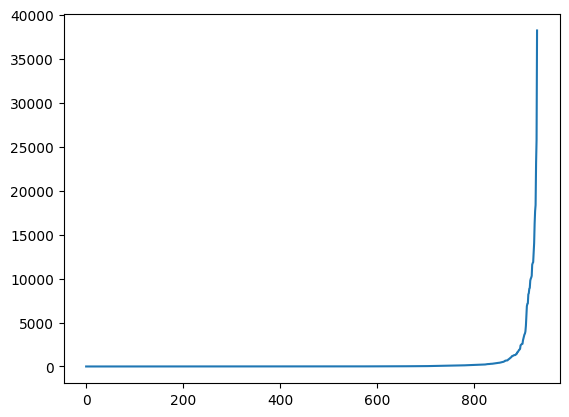

In [27]:
frequencia.sort_values().reset_index(drop=True).plot()

In [28]:
# Testando cenários de corte para redução de dimensionalidade baseados na frequencia
for corte in [5, 10, 20, 50, 100]:
    print(f'>= {corte}: {(frequencia >= corte).sum()} exames')

>= 5: 494 exames
>= 10: 392 exames
>= 20: 314 exames
>= 50: 225 exames
>= 100: 171 exames


Após estudo notou-se que ainda não é possível estabelecer um ponto de corte ideal e plausível. A seguir a abordagem adotada foi através de porcentagem.

In [29]:
# Trazendo a porcentagem de frequencia de exames 
total = len(df)

for p in [0.001, 0.005, 0.01, 0.02]:
    limite = total * p
    print(f'>= {p*100:.1f}%: {(frequencia >= limite).sum()} exames')

>= 0.1%: 220 exames
>= 0.5%: 104 exames
>= 1.0%: 71 exames
>= 2.0%: 55 exames


**Definição do ponto de corte**<br>
Com base na análise da distribuição de frequência dos exames, foi adotado um critério de corte visando equilibrar a redução da dimensionalidade com a preservação de padrões relevantes nos dados.

Observou-se que, ao considerar apenas exames com frequência mínima de 1% do total de registros, obtém-se um subconjunto de aproximadamente 71 exames mais frequentes, a partir de um total inicial de 931.

Essa abordagem permite reduzir significativamente a dimensionalidade do problema, ao mesmo tempo em que mantém os exames com maior representatividade estatística no dataset. Como resultado, espera-se melhorar a qualidade da clusterização, reduzindo ruído e aumentando a capacidade do modelo de identificar padrões consistentes.

Essa decisão busca um equilíbrio entre simplicidade e preservação de informação, garantindo que a análise permaneça robusta e interpretável.

In [30]:
# Cortando lista de valores únicos com base na análise feita anteriormente

# definindo limite de 1%
limite = len(df) * 0.01

exames_relevantes = frequencia[frequencia >= limite].index

# Aplica o corte
df['Exames_filtrados'] = df['Exames'].apply(
    lambda x: [
        e.strip() for e in x.split(',')
        if e.strip() in exames_relevantes
    ]
)

In [31]:
# Validando corte
df['Exames_filtrados'].explode().nunique()

71

In [32]:
# Checando se há listas vazias após a aplicação dos passo anteriores.
total = len(df)

vazios = (df['Exames_filtrados'].str.len() == 0).sum()

print(f'Listas vazias: {vazios} ({(vazios/total)*100:.2f}%)')

Listas vazias: 1992 (3.90%)


Com base no critério de frequência adotado (mínimo de 1% do total de registros), observou-se que aproximadamente 3,90% dos registros do dataset passaram a não apresentar exames relevantes após a etapa de filtragem.

Esses casos correspondem a registros compostos exclusivamente por exames de baixa frequência (raros), que não contribuem para a identificação de padrões consistentes no contexto da análise proposta.

Dessa forma, optou-se pela remoção desses registros, uma vez que sua permanência poderia introduzir ruído no modelo, especialmente em algoritmos de clusterização, que dependem de similaridade entre observações para formação de grupos.

Essa decisão visa garantir maior coerência analítica, mantendo apenas registros com informação relevante para a identificação de padrões de solicitação de exames laboratoriais

In [33]:
# removendo listas vazias
df = df[df['Exames_filtrados'].str.len() > 0]

In [34]:
# Validando as colunas
df[['Exames', 'Exames_filtrados']].head(30)

,Exames,Exames_filtrados
0,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GASOV","[HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GASOV]"
1,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GASOV","[HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GASOV]"
2,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GASOV,...","[HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GASOV..."
3,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GASOV","[HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GASOV]"
4,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GAS","[HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GAS]"
5,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GAS, D...","[HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GAS]"
6,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GAS","[HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GAS]"
7,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, ACLAT,...","[HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, CPK, ..."
8,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GAS, A...","[HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GAS]"
9,"HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GASOV","[HG, SOD, POT, URE, CRE, PCRU, CAI, MAG, GASOV]"


In [35]:
df['Exames_filtrados'].apply(len).value_counts().head(10)

Exames_filtrados
1     9720
2     5638
6     4259
5     3243
7     2999
3     2525
4     2193
8     1907
9     1875
10    1428
Name: count, dtype: int64

In [36]:
df['Exames_filtrados'].explode().value_counts().head(10)

Exames_filtrados
HG     38226
CRE    25761
URE    23149
POT    18366
SOD    17678
URI    16238
TRI    14040
GLI    12979
TGO    11866
TGP    11761
Name: count, dtype: int64

**One-Hot Encoding da variável Exames_filtrados**

In [37]:

# trasformando cada objeto da lista em colunas
df_exploded = df.explode('Exames_filtrados')

# Aplicando a codificação Onde-Hot
df_codf = pd.get_dummies(df_exploded['Exames_filtrados'])

# Agrupando os dataset
df_codf = df_codf.groupby(df_exploded.index).max()

In [38]:
# Juntando os dataset
df = pd.concat([df, df_codf], axis=1)

In [39]:
# Validando codificação
df_codf.shape

(49130, 71)

In [40]:
# Removendo colunas antiga de exames e exames filtrados
df = df.drop(columns=['Exames', 'Exames_filtrados'])

In [41]:
# Removendo colunas que não vão para o modelo
df_codf = df_codf.drop(columns=['Código', 'Data Cad.'], errors='ignore')

In [42]:
df_codf.shape

(49130, 71)

In [43]:
# Convertendo bool em 0 e 1
df_codf = df_codf.astype(int)

In [44]:
df_codf.head()

,AFO,ALB,AMI,AUR,BIL,CAI,CAS,CCCT,COAGU,COL,...,URC,URE,URI,V12,VD,VDR,VHS,VITAC,VLDL,ZIN
0,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [45]:
# Validando antes de modelar
df_codf.info()


<class 'pandas.DataFrame'>
Index: 49130 entries, 0 to 52728
Data columns (total 71 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   AFO     49130 non-null  int64
 1   ALB     49130 non-null  int64
 2   AMI     49130 non-null  int64
 3   AUR     49130 non-null  int64
 4   BIL     49130 non-null  int64
 5   CAI     49130 non-null  int64
 6   CAS     49130 non-null  int64
 7   CCCT    49130 non-null  int64
 8   COAGU   49130 non-null  int64
 9   COL     49130 non-null  int64
 10  COVDA   49130 non-null  int64
 11  CPK     49130 non-null  int64
 12  CRE     49130 non-null  int64
 13  DENGM   49130 non-null  int64
 14  ESTR    49130 non-null  int64
 15  FAL     49130 non-null  int64
 16  FER     49130 non-null  int64
 17  FOS     49130 non-null  int64
 18  FSH     49130 non-null  int64
 19  FTI     49130 non-null  int64
 20  GAS     49130 non-null  int64
 21  GASOV   49130 non-null  int64
 22  GGT     49130 non-null  int64
 23  GLI     49130 non-null  int

### Modelagem


Para o pré-processamento, aplicou-se a Padronização (StandardScaler). Esta etapa é mandatória para o algoritmo K-Means, pois este utiliza a Distância Euclidiana; sem o escalonamento, variáveis com magnitudes superiores enviesariam a formação dos clusters.

In [46]:
# Padronização StandardScaler

# Chamando a função scaler
scaler = StandardScaler()

# Aplicando 
x_scaled = scaler.fit_transform(df_codf)



### KMeans


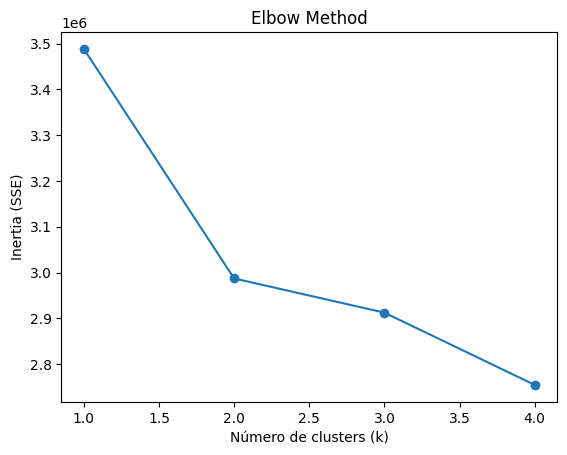

In [47]:
# Aplicando KMeans

inertia = []
k_range = range(1, 5)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method')
plt.show()

In [48]:
# Aplicando silhouette Score
for k in range(2, 3):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    print(f'k={k}, silhouette={score:.3f}')

k=2, silhouette=0.325


In [49]:
# Aplicando KMeans
kmeans = KMeans(n_clusters= 2, random_state=42)
df_codf['cluster'] = kmeans.fit_predict(x_scaled)

In [50]:
cluster_profile = df_codf.groupby('cluster').mean()

In [51]:
# Extraindo exames específicos do cluster 0
cluster_profile.T.sort_values(by=0, ascending=False).head(10)# .t. faz transposição de linhas para colunas

cluster,0,1
HG,0.953811,0.726850
TSH,0.886694,0.045788
GLI,0.863870,0.089315
VD,0.813532,0.024970
CRE,0.792242,0.445972
V12,0.787731,0.027126
HBGLI,0.779883,0.038691
TRI,0.751737,0.017190
COL,0.742625,0.015771
T4L,0.726567,0.022973


In [52]:
# Extraindo exames específicos do cluster 0
cluster_profile.T.sort_values(by=1, ascending=False).head(10)# .t. faz transposição de linhas para colunas

cluster,0,1
HG,0.953811,0.726850
CRE,0.792242,0.445972
URE,0.613622,0.429413
POT,0.394948,0.367591
SOD,0.358863,0.359995
PCRU,0.051150,0.256170
URI,0.608660,0.249468
COAGU,0.067930,0.160678
TGO,0.713487,0.103877
TGP,0.707984,0.102694


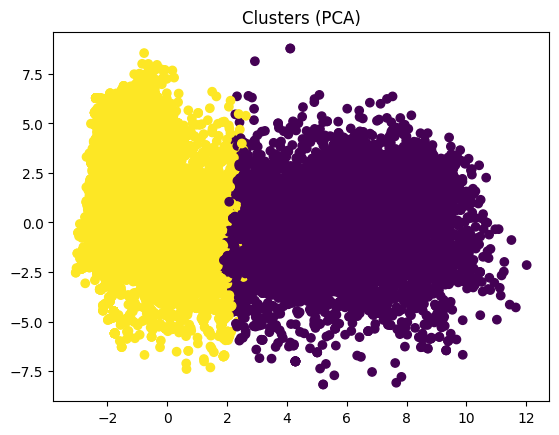

In [53]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df_codf['cluster'])
plt.title('Clusters (PCA)')
plt.show()

Os dados têm 2 estruturas principais, mas não são perfeitamente separáveis.

Fazendo análise dos cluster:

In [54]:
# Obtendo a proporção de cada cluster
df_codf['cluster'].value_counts(normalize=True)

cluster
1    0.774374
0    0.225626
Name: proportion, dtype: float64

Cluster 0 - 22,5%<br>
Cluster 1 - 77,4%<br>


A análise de clusterização indicou a presença de dois grupos principais no conjunto de dados.

O primeiro grupo concentra solicitações de baixa complexidade, com poucos exames por registro, caracterizando atendimentos rápidos e pontuais, típicos de rotina hospitalar ou triagem.

O segundo grupo apresenta maior densidade e diversidade de exames, incluindo combinações metabólicas, hormonais e bioquímicas, sugerindo perfis de investigação clínica mais aprofundada, possivelmente associados ao contexto ambulatorial ou acompanhamento de pacientes.

Essa segmentação evidencia que as solicitações laboratoriais não ocorrem de forma aleatória, mas seguem padrões distintos de complexidade, com implicações diretas na carga operacional e no consumo de recursos do laboratório.

In [55]:
# Entender qual cluster gera mais volumende exames
df_codf.groupby('cluster').sum().sum(axis = 1)

cluster
0    200794
1    175182
dtype: int64

In [56]:
df_codf['qtd_exames'] = df_codf.drop('cluster', axis=1).sum(axis=1)

df_codf.groupby('cluster')['qtd_exames'].mean()

cluster
0    18.114028
1     4.604600
Name: qtd_exames, dtype: float64

Existe uma concentração de complexidade no cluster minoritário.

Apesar de representar apenas 22,5% dos atendimentos, o cluster de maior complexidade concentra maior volume total de exames e apresenta, em média, quase quatro vezes mais exames por paciente, evidenciando uma concentração significativa de consumo de recursos laboratoriais.

In [57]:
# Criando dataset para exportação
df_long = df_codf.melt(
    id_vars=['cluster', 'qtd_exames'],
    var_name='exame',
    value_name='presenca'
)

df_long = df_long[df_long['presenca'] == 1]

In [58]:
# exportando o datasrt tratado.
df_codf.to_csv('dados_clusterizados.csv', index=False)
df_long.to_csv('dados_long.csv', index=False)